In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import skimage as ski
from natsort import natsorted
from plate_segmentation import PlateSegmenter
from tqdm.notebook import tqdm

In [2]:
# get file paths to phenotype-o-mat image data
input_directory = Path(
    "/Users/ryanlane/Projects/2024-segment-colonies/data/phenotype-o-mat/2024-09-16"
)
jpg_filepaths = natsorted(input_directory.glob("*.jpg"))

### Single image

In [3]:
# optional segmentation parameters
apply_watershed = True
footprint_size = 48
min_colony_size_px2 = 30
max_colony_size_px2= 1000
min_colony_eccentricity = 0.7
sigma_low = 1
sigma_high = 16

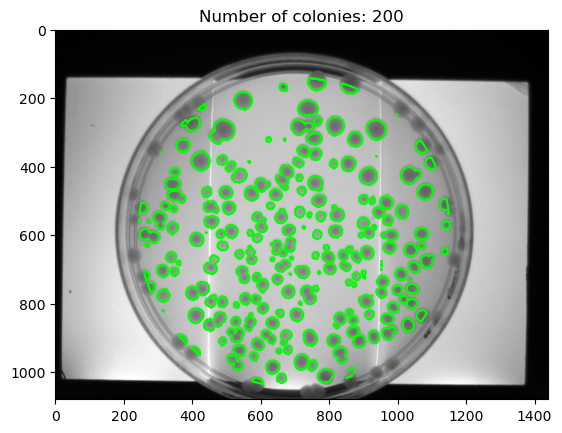

In [4]:
# load phenotype-o-mat image
filename = jpg_filepaths[1]
raw_plate_image = ski.io.imread(filename)
plate_segmenter = PlateSegmenter(
    filename=filename,
    apply_watershed=apply_watershed,
    footprint_size=footprint_size,
    min_colony_size_px2=min_colony_size_px2,
    max_colony_size_px2=max_colony_size_px2,
    min_colony_eccentricity=min_colony_eccentricity,
    sigma_low=sigma_low,
    sigma_high=sigma_high,
)
# segment colonies
segmented_plate_image = plate_segmenter.segment()

# plot raw image
fig, ax = plt.subplots()
ax.imshow(raw_plate_image, cmap="Greys_r")

# plot contours of each detected colony
colony_segments = ski.measure.regionprops(segmented_plate_image)
for i, _ in enumerate(colony_segments):
    contour = ski.measure.find_contours(segmented_plate_image == i)[0]
    ax.plot(contour[:, 1], contour[:, 0], color="#00ff00")

# aesthetics
title = f"Number of colonies: {len(colony_segments)}"
ax.set_title(title);

### Batch of images

  0%|          | 0/5 [00:00<?, ?it/s]

Output
------
Colonies detected: 1046
Colonies detected: 227
Colonies detected: 30
Colonies detected: 54
Colonies detected: 81


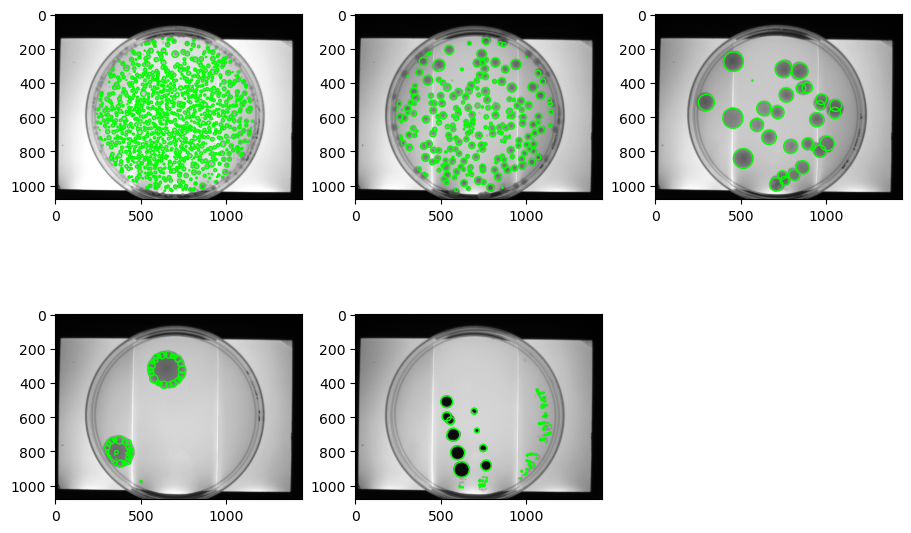

In [5]:
# create figure
ncols = 3
nrows = int(math.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

#
out = """\
Output
------"""

for i, jpg_filepath in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):

    raw_plate_image = ski.io.imread(jpg_filepath)
    plate_segmenter = PlateSegmenter(
        filename=jpg_filepath,
        min_colony_size_px2=min_colony_size_px2,
        max_colony_size_px2=max_colony_size_px2,
        min_colony_eccentricity=min_colony_eccentricity
    )
    segmented_plate_image = plate_segmenter.segment()

    axes.flat[i].imshow(raw_plate_image, cmap="Greys_r")

    colony_segments = ski.measure.regionprops(segmented_plate_image)
    for colony_segment in colony_segments:
        center = colony_segment.centroid[::-1]
        radius = math.sqrt(colony_segment.area / math.pi)
        patch = Circle(center, radius, facecolor="none", edgecolor="#00ff00")
        axes.flat[i].add_patch(patch)

    #
    # axes.flat[i].set_title(jpg_filepath.name)

    # append colony count
    out += f"\nColonies detected: {len(colony_segments)}"

# delete empty axes
[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];
print(out)